In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import glob
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau



Mounted at /content/drive


In [ ]:
import os
import shutil

drive_train_dir = '/content/drive/MyDrive/disease/Train'
local_train_dir = '/content/local_dataset/Train'

# Create the local directory if it doesn't exist
os.makedirs(local_train_dir, exist_ok=True)

# Copy the contents of the Drive directory to the local directory
# This might take some time depending on the size of your dataset
try:
    for item in os.listdir(drive_train_dir):
        s = os.path.join(drive_train_dir, item)
        d = os.path.join(local_train_dir, item)
        if os.path.isdir(s):
            shutil.copytree(s, d, False, None)
        else:
            shutil.copy2(s, d)
    print(f"✅ Successfully copied data from {drive_train_dir} to {local_train_dir}")
except FileNotFoundError:
    print(f"❌ Error: Source directory not found at {drive_train_dir}")
except Exception as e:
    print(f"❌ An error occurred during copying: {e}")

✅ Successfully copied data from /content/drive/MyDrive/disease/Train to /content/local_dataset/Train


In [ ]:
# Paths
train_dir = "/content/local_dataset/Train"
CHECKPOINT_DIR = "/content/drive/MyDrive/disease/checkpoints_inceptionv3"
HISTORY_PATH = "/content/drive/MyDrive/disease/inception_history.json"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Hyperparameters
image_size = (299, 299)
batch_size = 32
NORMAL_TRAIN_EPOCHS = 40
FINE_TUNE_EPOCHS = 30


In [ ]:
classes = []
class_counts = {}
total_images = 0

for entry in sorted(os.listdir(train_dir)):
    full = os.path.join(train_dir, entry)
    if os.path.isdir(full):
        classes.append(entry)
        cnt = sum([len(files) for _,_,files in os.walk(full)])
        class_counts[entry] = cnt
        total_images += cnt

print("📊 Classes and image counts:")
print(class_counts)
print(f"\nTotal images: {total_images}")
num_classes = len(classes)
print(f"Number of classes: {num_classes}")


📊 Classes and image counts:
{'Leaf Miner': 799, 'Spotted Wilt Virus': 472, 'Tomato___Bacterial_spot': 1000, 'Tomato___Early_blight': 1000, 'Tomato___Late_blight': 1000, 'Tomato___Leaf_Mold': 1000, 'Tomato___Septoria_leaf_spot': 1010, 'Tomato___Spider_mites Two-spotted_spider_mite': 1000, 'Tomato___Target_Spot': 1000, 'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 43, 'Tomato___Tomato_mosaic_virus': 1000, 'Tomato___healthy': 1000}

Total images: 10324
Number of classes: 12


In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)


Found 10324 images belonging to 12 classes.


In [ ]:
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))

for layer in base_model.layers:
    layer.trainable = False  # Freeze all layers

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Define callbacks before using them
checkpoint = ModelCheckpoint(
    filepath='/content/drive/MyDrive/tomato_leaf_disease_accuracy.h5',
    save_weights_only=False,
    save_best_only=True,  # Set to True to save only the best model based on monitor
    monitor='accuracy', # Monitor accuracy
    verbose=1
)

lr_scheduler = ReduceLROnPlateau(
    monitor='loss',
    factor=0.2,
    patience=5,
    verbose=1,
    min_lr=1e-6
)

callbacks = [checkpoint, lr_scheduler]

initial_epochs = 40 # You can adjust this

history = model.fit(
    train_generator,
    epochs=initial_epochs,
    callbacks=callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 733ms/step - accuracy: 0.3049 - loss: 2.0621
Epoch 1: accuracy improved from -inf to 0.42842, saving model to /content/drive/MyDrive/tomato_leaf_disease_accuracy.h5


323/323 ━━━━━━━━━━━━━━━━━━━━ 261s 736ms/step - accuracy: 0.3053 - loss: 2.0610 - learning_rate: 1.0000e-04
Epoch 2/40
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 700ms/step - accuracy: 0.5937 - loss: 1.1827
Epoch 2: accuracy improved from 0.42842 to 0.61197, saving model to /content/drive/MyDrive/tomato_leaf_disease_accuracy.h5


323/323 ━━━━━━━━━━━━━━━━━━━━ 230s 710ms/step - accuracy: 0.5938 - loss: 1.1825 - learning_rate: 1.0000e-04
Epoch 3/40
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 702ms/step - accuracy: 0.6530 - loss: 1.0146
Epoch 3: accuracy improved from 0.61197 to 0.65740, saving model to /content/drive/MyDrive/tomato_leaf_disease_accuracy.h5


323/323 ━━━━━━━━━━━━━━━━━━━━ 230s 711ms/step - accuracy: 0.6530 - loss: 1.0145 - learning_rate: 1.0000e-04
Epoch 4/40
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 705ms/step - accuracy: 0.6792 - loss: 0.9463
Epoch 4: accuracy improved from 0.65740 to 0.68723, saving model to /content/drive/MyDrive/tomato_leaf_disease_accuracy.h5


...

323/323 ━━━━━━━━━━━━━━━━━━━━ 225s 698ms/step - accuracy: 0.7915 - loss: 0.5984 - learning_rate: 1.0000e-04
Epoch 32/40
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 693ms/step - accuracy: 0.7848 - loss: 0.6133
Epoch 32: accuracy improved from 0.78962 to 0.79068, saving model to /content/drive/MyDrive/tomato_leaf_disease_accuracy.h5


323/323 ━━━━━━━━━━━━━━━━━━━━ 227s 702ms/step - accuracy: 0.7848 - loss: 0.6133 - learning_rate: 1.0000e-04
Epoch 33/40
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 689ms/step - accuracy: 0.7999 - loss: 0.5723
Epoch 33: accuracy improved from 0.79068 to 0.79436, saving model to /content/drive/MyDrive/tomato_leaf_disease_accuracy.h5


323/323 ━━━━━━━━━━━━━━━━━━━━ 226s 697ms/step - accuracy: 0.7999 - loss: 0.5723 - learning_rate: 1.0000e-04
Epoch 34/40
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 692ms/step - accuracy: 0.7950 - loss: 0.5834
Epoch 34: accuracy did not improve from 0.79436
323/323 ━━━━━━━━━━━━━━━━━━━━ 224s 692ms/step - accuracy: 0.7950 - loss: 0.5835 - learning_rate: 1.0000e-04
Epoch 35/40
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 684ms/step - accuracy: 0.7983 - loss: 0.5666
Epoch 35: accuracy improved from 0.79436 to 0.79601, saving model to /content/drive/MyDrive/tomato_leaf_disease_accuracy.h5


323/323 ━━━━━━━━━━━━━━━━━━━━ 224s 692ms/step - accuracy: 0.7983 - loss: 0.5667 - learning_rate: 1.0000e-04
Epoch 36/40
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 691ms/step - accuracy: 0.7976 - loss: 0.5781
Epoch 36: accuracy did not improve from 0.79601
323/323 ━━━━━━━━━━━━━━━━━━━━ 223s 691ms/step - accuracy: 0.7975 - loss: 0.5782 - learning_rate: 1.0000e-04
Epoch 37/40
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 698ms/step - accuracy: 0.8022 - loss: 0.5796
Epoch 37: accuracy did not improve from 0.79601
323/323 ━━━━━━━━━━━━━━━━━━━━ 226s 698ms/step - accuracy: 0.8022 - loss: 0.5796 - learning_rate: 1.0000e-04
Epoch 38/40
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 703ms/step - accuracy: 0.7987 - loss: 0.5523
Epoch 38: accuracy improved from 0.79601 to 0.79727, saving model to /content/drive/MyDrive/tomato_leaf_disease_accuracy.h5


323/323 ━━━━━━━━━━━━━━━━━━━━ 230s 711ms/step - accuracy: 0.7987 - loss: 0.5523 - learning_rate: 1.0000e-04
Epoch 39/40
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 698ms/step - accuracy: 0.7966 - loss: 0.5591
Epoch 39: accuracy did not improve from 0.79727
323/323 ━━━━━━━━━━━━━━━━━━━━ 226s 698ms/step - accuracy: 0.7966 - loss: 0.5591 - learning_rate: 1.0000e-04
Epoch 40/40
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 693ms/step - accuracy: 0.7985 - loss: 0.5663
Epoch 40: accuracy did not improve from 0.79727
323/323 ━━━━━━━━━━━━━━━━━━━━ 224s 693ms/step - accuracy: 0.7985 - loss: 0.5663 - learning_rate: 1.0000e-04


In [ ]:
# Unfreeze the top N layers of InceptionV3 base model for fine-tuning
fine_tune_at = 249  # Typically, last 50 layers. Adjust as needed.

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base_model.layers[fine_tune_at:]:
    layer.trainable = True

# Re-compile the model with a lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_epochs = 30
total_epochs = initial_epochs + fine_tune_epochs

history_finetune = model.fit(
    train_generator,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1]+1,
    callbacks=callbacks
)


Epoch 41/70
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 740ms/step - accuracy: 0.4818 - loss: 2.1961
Epoch 41: accuracy did not improve from 0.79727
323/323 ━━━━━━━━━━━━━━━━━━━━ 265s 740ms/step - accuracy: 0.4823 - loss: 2.1932 - learning_rate: 1.0000e-05
Epoch 42/70
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 715ms/step - accuracy: 0.7889 - loss: 0.6093
Epoch 42: accuracy improved from 0.79727 to 0.80172, saving model to /content/drive/MyDrive/tomato_leaf_disease_accuracy.h5


323/323 ━━━━━━━━━━━━━━━━━━━━ 234s 724ms/step - accuracy: 0.7889 - loss: 0.6092 - learning_rate: 1.0000e-05
Epoch 43/70
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 713ms/step - accuracy: 0.8332 - loss: 0.4735
Epoch 43: accuracy improved from 0.80172 to 0.83659, saving model to /content/drive/MyDrive/tomato_leaf_disease_accuracy.h5


323/323 ━━━━━━━━━━━━━━━━━━━━ 235s 726ms/step - accuracy: 0.8332 - loss: 0.4735 - learning_rate: 1.0000e-05
Epoch 44/70
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 714ms/step - accuracy: 0.8541 - loss: 0.4199
Epoch 44: accuracy improved from 0.83659 to 0.85945, saving model to /content/drive/MyDrive/tomato_leaf_disease_accuracy.h5


323/323 ━━━━━━━━━━━━━━━━━━━━ 235s 728ms/step - accuracy: 0.8541 - loss: 0.4199 - learning_rate: 1.0000e-05
Epoch 45/70
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 717ms/step - accuracy: 0.8682 - loss: 0.3706
Epoch 45: accuracy improved from 0.85945 to 0.87282, saving model to /content/drive/MyDrive/tomato_leaf_disease_accuracy.h5


323/323 ━━━━━━━━━━━━━━━━━━━━ 238s 736ms/step - accuracy: 0.8682 - loss: 0.3706 - learning_rate: 1.0000e-05
Epoch 46/70
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 709ms/step - accuracy: 0.8868 - loss: 0.3234
Epoch 46: accuracy improved from 0.87282 to 0.88812, saving model to /content/drive/MyDrive/tomato_leaf_disease_accuracy.h5


...

323/323 ━━━━━━━━━━━━━━━━━━━━ 235s 727ms/step - accuracy: 0.9621 - loss: 0.1001 - learning_rate: 1.0000e-05
Epoch 63/70
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 718ms/step - accuracy: 0.9612 - loss: 0.1066
Epoch 63: accuracy did not improve from 0.96116
323/323 ━━━━━━━━━━━━━━━━━━━━ 232s 718ms/step - accuracy: 0.9612 - loss: 0.1066 - learning_rate: 1.0000e-05
Epoch 64/70
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 705ms/step - accuracy: 0.9663 - loss: 0.0945
Epoch 64: accuracy improved from 0.96116 to 0.96474, saving model to /content/drive/MyDrive/tomato_leaf_disease_accuracy.h5


323/323 ━━━━━━━━━━━━━━━━━━━━ 240s 743ms/step - accuracy: 0.9663 - loss: 0.0945 - learning_rate: 1.0000e-05
Epoch 65/70
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 724ms/step - accuracy: 0.9686 - loss: 0.0891
Epoch 65: accuracy improved from 0.96474 to 0.96707, saving model to /content/drive/MyDrive/tomato_leaf_disease_accuracy.h5


323/323 ━━━━━━━━━━━━━━━━━━━━ 239s 740ms/step - accuracy: 0.9686 - loss: 0.0891 - learning_rate: 1.0000e-05
Epoch 66/70
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 725ms/step - accuracy: 0.9680 - loss: 0.0845
Epoch 66: accuracy did not improve from 0.96707
323/323 ━━━━━━━━━━━━━━━━━━━━ 234s 725ms/step - accuracy: 0.9680 - loss: 0.0845 - learning_rate: 1.0000e-05
Epoch 67/70
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 708ms/step - accuracy: 0.9695 - loss: 0.0851
Epoch 67: accuracy did not improve from 0.96707
323/323 ━━━━━━━━━━━━━━━━━━━━ 229s 708ms/step - accuracy: 0.9695 - loss: 0.0851 - learning_rate: 1.0000e-05
Epoch 68/70
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 704ms/step - accuracy: 0.9723 - loss: 0.0810
Epoch 68: accuracy improved from 0.96707 to 0.97133, saving model to /content/drive/MyDrive/tomato_leaf_disease_accuracy.h5


323/323 ━━━━━━━━━━━━━━━━━━━━ 235s 728ms/step - accuracy: 0.9723 - loss: 0.0810 - learning_rate: 1.0000e-05
Epoch 69/70
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 712ms/step - accuracy: 0.9708 - loss: 0.0835
Epoch 69: accuracy did not improve from 0.97133
323/323 ━━━━━━━━━━━━━━━━━━━━ 230s 712ms/step - accuracy: 0.9707 - loss: 0.0835 - learning_rate: 1.0000e-05
Epoch 70/70
323/323 ━━━━━━━━━━━━━━━━━━━━ 0s 701ms/step - accuracy: 0.9712 - loss: 0.0773
Epoch 70: accuracy improved from 0.97133 to 0.97181, saving model to /content/drive/MyDrive/tomato_leaf_disease_accuracy.h5


323/323 ━━━━━━━━━━━━━━━━━━━━ 235s 729ms/step - accuracy: 0.9712 - loss: 0.0773 - learning_rate: 1.0000e-05


In [ ]:
model.save('/content/drive/MyDrive/disease/tomato_leaf_disease.h5')
print("✅ Current model saved successfully in .h5 format!")

model.save('/content/drive/MyDrive/disease/tomato_leaf_disease.keras')
print("✅ Current model saved successfully in .keras format!")

✅ Current model saved successfully in .h5 format!
✅ Current model saved successfully in .keras format!


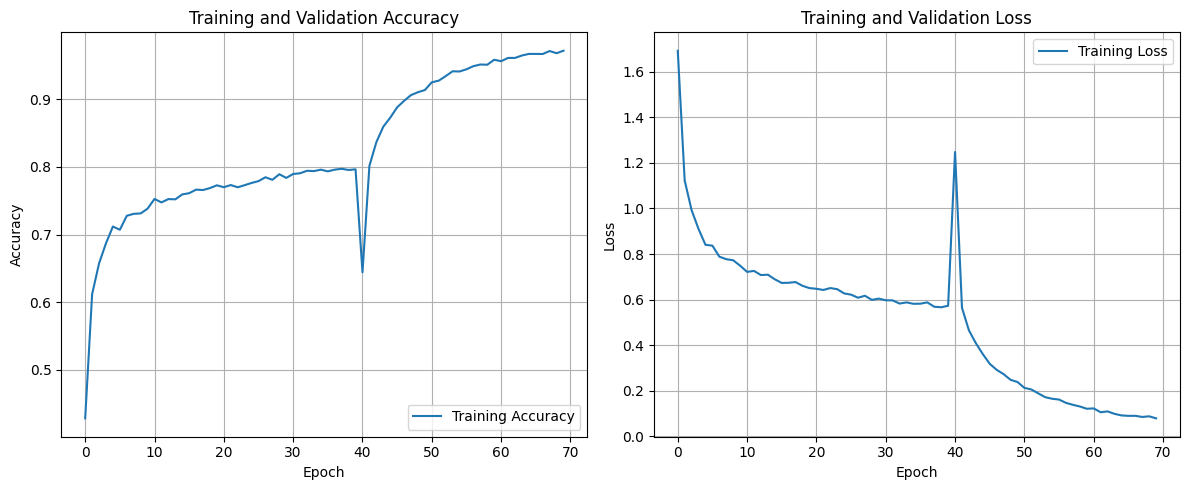

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Combine history objects
# Make sure 'history' and 'history_finetune' are available from previous runs

# Safely get history data, handling cases where a history object might not exist or be empty
def get_history_data(history_obj, key):
    if history_obj and hasattr(history_obj, 'history') and key in history_obj.history:
        return history_obj.history[key]
    return []

acc = get_history_data(history, 'accuracy')
val_acc = get_history_data(history, 'val_accuracy') # If validation data was used

loss = get_history_data(history, 'loss')
val_loss = get_history_data(history, 'val_loss') # If validation data was used

# Append fine-tune history if available
acc.extend(get_history_data(history_finetune, 'accuracy'))
val_acc.extend(get_history_data(history_finetune, 'val_accuracy'))

loss.extend(get_history_data(history_finetune, 'loss'))
val_loss.extend(get_history_data(history_finetune, 'val_loss'))

epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
if val_acc: # Plot validation accuracy only if it exists
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
if val_loss: # Plot validation loss only if it exists
    plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.tight_layout()
plt.show()


In [ ]:
import os
import shutil

drive_train_dir = '/content/drive/MyDrive/disease/Test'
local_train_dir = '/content/local_dataset/Test'

# Create the local directory if it doesn't exist
os.makedirs(local_train_dir, exist_ok=True)

# Copy the contents of the Drive directory to the local directory
# This might take some time depending on the size of your dataset
try:
    for item in os.listdir(drive_train_dir):
        s = os.path.join(drive_train_dir, item)
        d = os.path.join(local_train_dir, item)
        if os.path.isdir(s):
            shutil.copytree(s, d, False, None)
        else:
            shutil.copy2(s, d)
    print(f"✅ Successfully copied data from {drive_train_dir} to {local_train_dir}")
except FileNotFoundError:
    print(f"❌ Error: Source directory not found at {drive_train_dir}")
except Exception as e:
    print(f"❌ An error occurred during copying: {e}")

✅ Successfully copied data from /content/drive/MyDrive/disease/Test to /content/local_dataset/Test


In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 📂 Set test dataset directory
test_dir = '/content/local_dataset/Test'  # Update if needed

# 🧭 Use the same class indices as training
class_indices = train_generator.class_indices
class_names = list(class_indices.keys())

img_size = 299  # InceptionV3 image size
X_test_list, y_test = [], []

for cls in class_names:
    class_path = os.path.join(test_dir, cls)
    if not os.path.exists(class_path):
        continue
    for file in os.listdir(class_path):
        img_path = os.path.join(class_path, file)
        img = cv2.imread(img_path)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (img_size, img_size))
        X_test_list.append(img)
        y_test.append(class_indices[cls])

X_test = np.array(X_test_list, dtype=np.float32) / 255.0
y_test = np.array(y_test)

print(f"✅ Loaded {len(X_test)} test images.")


✅ Loaded 1141 test images.


In [ ]:
# 🔄 Load your trained InceptionV3 model
model = tf.keras.models.load_model("/content/drive/MyDrive/disease/tomato_leaf_disease.keras")  # Adjust if needed

# One-hot encode y_test
y_test_encoded = tf.keras.utils.to_categorical(y_test, num_classes=len(class_names)).astype(np.int32)

# 🧪 Evaluate
test_loss, test_acc = model.evaluate(X_test, y_test_encoded, batch_size=1, verbose=2)
print(f"\n✅ Test Accuracy: {test_acc * 100:.2f}%")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 42 variables whereas the saved optimizer has 82 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


1141/1141 - 24s - 21ms/step - accuracy: 0.9518 - loss: 0.1428

✅ Test Accuracy: 95.18%


36/36 ━━━━━━━━━━━━━━━━━━━━ 26s 422ms/step


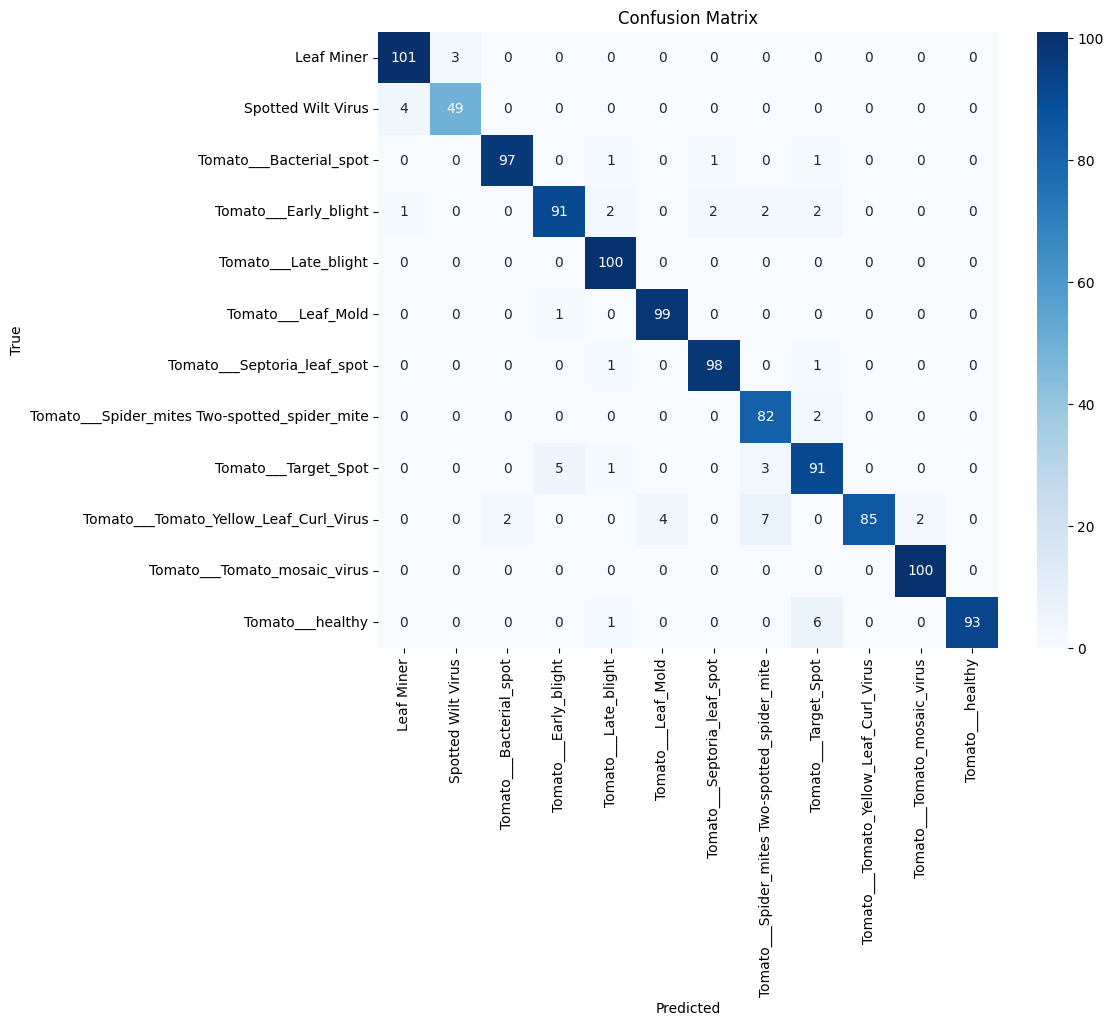


Classification Report:
                                                precision    recall  f1-score   support

                                   Leaf Miner       0.95      0.97      0.96       104
                           Spotted Wilt Virus       0.94      0.92      0.93        53
                      Tomato___Bacterial_spot       0.98      0.97      0.97       100
                        Tomato___Early_blight       0.94      0.91      0.92       100
                         Tomato___Late_blight       0.94      1.00      0.97       100
                           Tomato___Leaf_Mold       0.96      0.99      0.98       100
                  Tomato___Septoria_leaf_spot       0.97      0.98      0.98       100
Tomato___Spider_mites Two-spotted_spider_mite       0.87      0.98      0.92        84
                         Tomato___Target_Spot       0.88      0.91      0.90       100
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       1.00      0.85      0.92       100
                 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score

# 🔹 Ensure your test data is prepared
# X_test, y_test (integers 0..num_classes-1)
# class_labels = list(train_generator.class_indices.keys())

# 🔹 Make predictions
y_pred_prob = model.predict(X_test, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = y_test  # integer labels

# 🔹 Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# 🔹 Classification report (Precision, Recall, F1-score)
report = classification_report(y_true, y_pred, target_names=class_names)
print("\nClassification Report:\n", report)

# 🔹 Correct and Incorrect predictions per class
correct_per_class = np.diag(cm)            # diagonal of confusion matrix
total_per_class = np.sum(cm, axis=1)       # total samples per class
incorrect_per_class = total_per_class - correct_per_class

for i, class_name in enumerate(class_names):
    print(f"\nClass: {class_name}")
    print(f"Total samples     : {total_per_class[i]}")
    print(f"Correctly predicted: {correct_per_class[i]}")
    print(f"Incorrectly predicted: {incorrect_per_class[i]}")

# 🔹 Optional: Precision and recall per class
precision_per_class = precision_score(y_true, y_pred, average=None)
recall_per_class = recall_score(y_true, y_pred, average=None)

for i, class_name in enumerate(class_names):
    print(f"\nClass: {class_name}")
    print(f"Precision: {precision_per_class[i]:.2f}")
    print(f"Recall   : {recall_per_class[i]:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


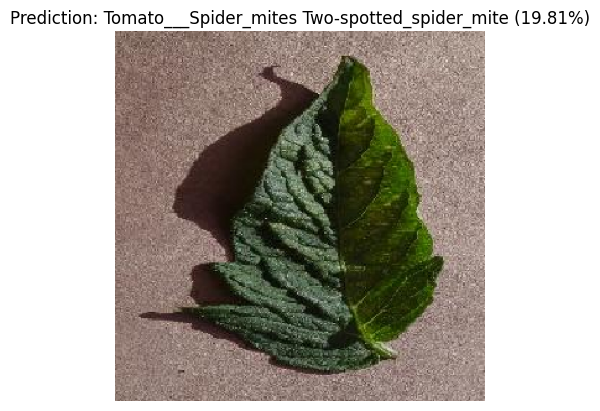

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing import image

# Specify the path to your image in Google Drive
image_path_from_drive = '/content/drive/MyDrive/disease/Test/Tomato___Spider_mites Two-spotted_spider_mite/00c8e9a0-1fb8-434b-8981-25511358ddc9___Com.G_SpM_FL 8717.JPG' # <--- REPLACE WITH YOUR IMAGE PATH

try:
    # 🖼️ Read and preprocess the image
    img = image.load_img(image_path_from_drive, target_size=image_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # Create a batch
    img_array /= 255.0  # Rescale

    # 🔮 Make a prediction
    predictions = model.predict(img_array)
    score = tf.nn.softmax(predictions[0])

    # 🎯 Get the predicted class and confidence
    predicted_class_index = np.argmax(score)
    predicted_class_name = class_names[predicted_class_index]
    confidence = 100 * np.max(score)

    # 📈 Display the image and prediction
    plt.imshow(img)
    plt.title(f"Prediction: {predicted_class_name} ({confidence:.2f}%)")
    plt.axis("off")
    plt.show()
except FileNotFoundError:
    print(f"Error: Image not found at '{image_path_from_drive}'")
except Exception as e:
    print(f"An error occurred: {e}")